In [2]:
import polars as pl 
import seaborn as sns
import matplotlib.pyplot as plt 
from dbconfig import engine
print('Environment ready')

Environment ready


In [40]:
from pathlib import Path 

plots_dir = Path('plots')
plots_dir.mkdir(exist_ok = True)

In [12]:
pl.Config.set_tbl_rows(50)
pl.Config.set_tbl_cols(30)
pl.Config.set_fmt_str_lengths(80)
pl.Config.set_tbl_width_chars(180)
pl.Config.set_float_precision(2)
pl.Config.set_thousands_separator(",")

polars.config.Config

In [13]:
pl.read_database(
        query = """
        select table_name, 
        column_name
        from information_schema.columns
        where table_schema = 'clean'
        order by table_name, ordinal_position;
        """, connection = engine
        )

table_name,column_name
str,str
"""categories""","""product_category_name"""
"""categories""","""product_category_name_english"""
"""customers""","""customer_id"""
"""customers""","""customer_unique_id"""
"""customers""","""customer_zip_code_prefix"""
"""customers""","""customer_city"""
"""customers""","""customer_state"""
"""order_items""","""order_id"""
"""order_items""","""order_item_id"""


In [46]:
revenue_df = pl.read_database(
        query = """
        select distinct(seller_id), sum(price) as revenue 
        from clean.order_items
        group by seller_id
        order by revenue desc;
        """, connection = engine
        )

In [17]:
print(revenue_df.shape)
print(revenue_df.describe())
print(revenue_df.head(10))

(3095, 2)
shape: (9, 3)
┌────────────┬──────────────────────────────────┬────────────┐
│ statistic  ┆ seller_id                        ┆ revenue    │
│ ---        ┆ ---                              ┆ ---        │
│ str        ┆ str                              ┆ f64        │
╞════════════╪══════════════════════════════════╪════════════╡
│ count      ┆ 3,095                            ┆ 3,095.00   │
│ null_count ┆ 0                                ┆ 0.00       │
│ mean       ┆ null                             ┆ 4,391.48   │
│ std        ┆ null                             ┆ 13,922.00  │
│ min        ┆ 0015a82c2db000af6aaaf3ae2ecb0532 ┆ 3.50       │
│ 25%        ┆ null                             ┆ 208.90     │
│ 50%        ┆ null                             ┆ 821.48     │
│ 75%        ┆ null                             ┆ 3,281.66   │
│ max        ┆ ffff564a4f9085cd26170f4732393726 ┆ 229,472.63 │
└────────────┴──────────────────────────────────┴────────────┘
shape: (10, 2)
┌───────────────

In [18]:
total_revenue = revenue_df['revenue'].sum()
revenue_df.head(10)['revenue'].sum()/total_revenue

0.13149562918574653

In [21]:
n = revenue_df.height

top_1_pct = int(n * 0.01)
top_5_pct = int(n * 0.05)
top_10_pct = int(n * 0.10)
top_20_pct = int(n * 0.20)


revenue_df.head(top_1_pct).select(
        (pl.col('revenue').sum() / total_revenue).alias('share')
        )

share
f64
0.26


In [22]:
revenue_df.head(top_5_pct).select(
        (pl.col('revenue').sum() / total_revenue).alias('share')
        )

share
f64
0.53


In [23]:
revenue_df.head(top_10_pct).select(
        (pl.col('revenue').sum() / total_revenue).alias('share')
        )

share
f64
0.67


In [24]:
revenue_df.head(top_20_pct).select(
        (pl.col('revenue').sum() / total_revenue).alias('share')
        )

share
f64
0.83


In [29]:
revenue_df.head(int(n * 0.50)).select(
        (pl.col('revenue').sum() / total_revenue).alias('share')
        )

share
f64
0.97


In [27]:
revenue_df.sort('revenue').head(int(n * 0.50)).select(
        (pl.col('revenue').sum() / total_revenue).alias('share')
        )

share
f64
0.03


In [47]:
revenue_df_cum = revenue_df.with_row_index('rank')

In [48]:
revenue_df_cum = revenue_df_cum.with_columns([
            ((pl.col('rank') + 1) / pl.len() * 100).alias('seller_pct'),
            (pl.col('revenue').cum_sum() / pl.col('revenue').sum() * 100).alias('revenue_pct')
            ])

In [49]:
plot_df = revenue_df_cum.to_pandas()

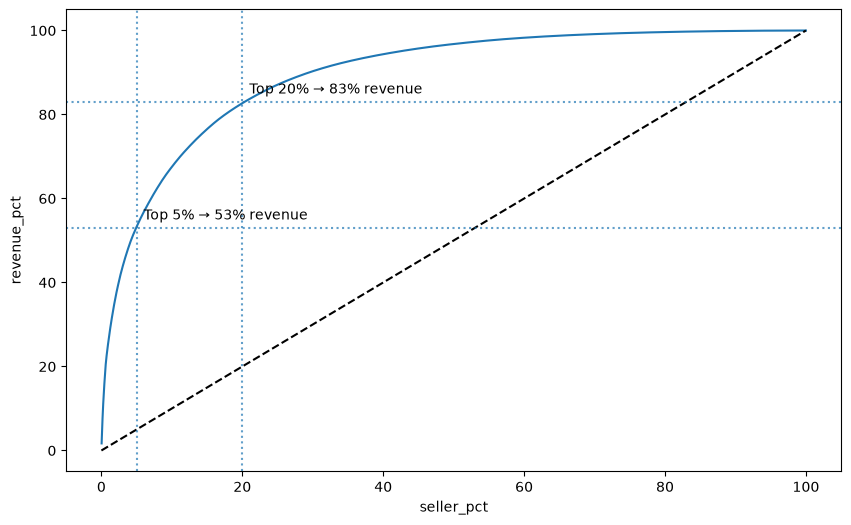

In [57]:
plt.figure(figsize = (10,6))
sns.lineplot(
        data = plot_df,
        x = 'seller_pct',
        y = 'revenue_pct'
        )
plt.plot([0, 100], [0, 100], 'k--')

plt.axvline(5, linestyle=":", alpha=0.7)
plt.axhline(53, linestyle=":", alpha=0.7)

plt.axvline(20, linestyle=":", alpha=0.7)
plt.axhline(83, linestyle=":", alpha=0.7)

plt.text(6, 55, "Top 5% → 53% revenue")
plt.text(21, 85, "Top 20% → 83% revenue")

plt.savefig(
        plots_dir / 'revenue_concentration.png',
        dpi = 300,
        bbox_inches = 'tight'
        )
plt.show()

In [50]:
revenue_df_lorenz = revenue_df.sort('revenue').with_row_index('rank')

In [51]:
revenue_df_lorenz = revenue_df_lorenz.with_columns([
            ((pl.col('rank') + 1) / pl.len() * 100).alias('seller_pct'),
            (pl.col('revenue').cum_sum() / pl.col('revenue').sum() * 100).alias('revenue_pct')
            ])

In [52]:
plot_df_lorenz = revenue_df_lorenz.to_pandas()

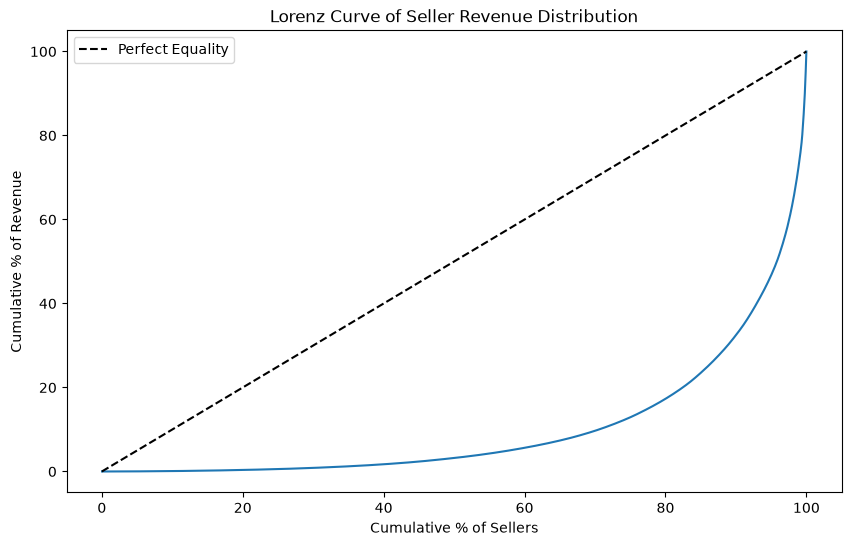

In [55]:
plt.figure(figsize = (10,6))

sns.lineplot(
        data = plot_df_lorenz,
        x = 'seller_pct',
        y = 'revenue_pct'
        )

plt.plot([0,100],[0,100], 'k--', label = 'Perfect Equality')

plt.xlabel("Cumulative % of Sellers")
plt.ylabel("Cumulative % of Revenue")
plt.title("Lorenz Curve of Seller Revenue Distribution")
plt.legend()

plt.savefig(
        plots_dir / 'lorenz_curve_revenue_distribution.png',
        dpi = 300,
        bbox_inches = 'tight'
        )

plt.show()

In [60]:
import numpy as np

x = revenue_df_lorenz["seller_pct"].to_numpy() / 100
y = revenue_df_lorenz["revenue_pct"].to_numpy() / 100

gini = 1 - 2 * np.trapezoid(y, x)

print(f"Gini Coefficient: {gini:.4f}")

Gini Coefficient: 0.7915


In [61]:
revenue_df_cum.write_database(
    table_name="analytics.revenue_concentration",
    connection=engine,
    if_table_exists="replace"
)

-1

In [62]:
revenue_df_lorenz.write_database(
    table_name="analytics.revenue_concentration_lorenz",
    connection=engine,
    if_table_exists="replace"
)

-1

In [63]:
pl.read_database(
        query = """
        select * 
        from analytics.revenue_concentration
        limit 5;
        """, connection = engine
        )

rank,seller_id,revenue,seller_pct,revenue_pct
i64,str,f64,f64,f64
0,"""4869f7a5dfa277a7dca6462dcf3b52b2""","229,472.63",0.03,1.69
1,"""53243585a1d6dc2643021fd1853d8905""","222,776.05",0.06,3.33
2,"""4a3ca9315b744ce9f8e9374361493884""","200,472.92",0.10,4.80
3,"""fa1c13f2614d7b5c4749cbc52fecda94""","194,042.03",0.13,6.23
4,"""7c67e1448b00f6e969d365cea6b010ab""","187,923.89",0.16,7.61
